# Assignment 3: Numerical Analysis for PDE's (WI3730TU)
### Numerical Solution of the Two-Dimensional Poisson Equation using Finite-Difference and Finite-Volume Methods

**Boundary-Value Problem Details:**
$$
-\nabla\cdot(k\nabla u) = f, \quad (x,y) \in \Omega = (0,10)\times(0,5)
$$
$$
u(x,y) = 0, \quad (x,y) \in \partial\Omega
$$
$$
f(x,y) = \sum_{i=1}^{9}\sum_{j=1}^{4}e^{-\alpha(x-i)^2-\alpha(y-j)^2}, \quad \alpha = 40
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as la
%matplotlib inline

# Domain parameters
LeftX, RightX = 0.0, 10.0
LeftY, RightY = 0.0, 5.0
Lx = RightX - LeftX
Ly = RightY - LeftY

## 📐 Section 1: Explicit Derivations & Discrete Formulations for 2D FDM

### Question 1.1: $\mathcal{O}(h^2)$ Finite-Difference Approximation (1 p)
Throughout the entirety of Section 1, we assume $k=1$ and the BV problem reduces to a negative 2D Laplacian.The central difference approximation for the negative Laplacian $-\Delta u$ at an internal grid node $(x_i, y_j)$ on a uniform Cartesian grid with unequal spacings ($h_x \neq h_y$) is given by:

$$
-\Delta u(x_i,y_j) = -\frac{\partial^2 u}{\partial x^2} -\frac{\partial^2 u}{\partial y^2}
$$

Using second-order central differences,

$$
-\frac{\partial^2 u}{\partial x^2}(x_i,y_j) \approx \frac{-u_{i-1,j}+2u_{i,j}-u_{i+1,j}}{h_x^2},
$$

and

$$
-\frac{\partial^2 u}{\partial y^2}(x_i,y_j) \approx \frac{-u_{i,j-1}+2u_{i,j}-u_{i,j+1}}{h_y^2}.
$$

Therefore,

$$
-\Delta u_{i,j} \approx \left( \frac{2}{h_x^2} + \frac{2}{h_y^2} \right)u_{i,j} - \frac{1}{h_x^2} \left( u_{i-1,j}+u_{i+1,j} \right) - \frac{1}{h_y^2} \left( u_{i,j-1}+u_{i,j+1} \right)

$$

with truncation error

$$
-\Delta u_{i,j} = \left( \frac{2}{h_x^2} + \frac{2}{h_y^2} \right)u_{i,j} - \frac{u_{i-1,j}+u_{i+1,j}}{h_x^2} - \frac{u_{i,j-1}+u_{i,j+1}}{h_y^2} + \mathcal{O}(h_x^2+h_y^2).
$$

### Question 1.2: Explicit Discrete Equations on a $4 \times 4$ Mesh (2 p)
Given $N_x = 4, N_y = 4 \implies h_x = \frac{10}{4} = 2.5$ and $h_y = \frac{5}{4} = 1.25$. With homogeneous Dirichlet boundary conditions ($u = 0$ on $\partial\Omega$), the boundary unknowns are eliminated, leaving 9 inner unknowns ordered lexicographically:
$$
\mathbf{u} = [u_{1,1}, u_{2,1}, u_{3,1}, u_{1,2}, u_{2,2}, u_{3,2}, u_{1,3}, u_{2,3}, u_{3,3}]^T
$$

The resulting algebraic equations at each interior point evaluate to:

$$
\begin{aligned}

\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{1,1}
-\frac{1}{h_x^2}u_{2,1}
-\frac{1}{h_y^2}u_{1,2}
&= f_{1,1}
\\

-\frac{1}{h_x^2}u_{1,1}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{2,1}
-\frac{1}{h_x^2}u_{3,1}
-\frac{1}{h_y^2}u_{2,2}
&= f_{2,1}
\\

-\frac{1}{h_x^2}u_{2,1}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{3,1}
-\frac{1}{h_y^2}u_{3,2}
&= f_{3,1}
\\[1mm]

-\frac{1}{h_y^2}u_{1,1}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{1,2}
-\frac{1}{h_x^2}u_{2,2}
-\frac{1}{h_y^2}u_{1,3}
&= f_{1,2}
\\

-\frac{1}{h_y^2}u_{2,1}
-\frac{1}{h_x^2}u_{1,2}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{2,2}
-\frac{1}{h_x^2}u_{3,2}
-\frac{1}{h_y^2}u_{2,3}
&= f_{2,2}
\\

-\frac{1}{h_y^2}u_{3,1}
-\frac{1}{h_x^2}u_{2,2}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{3,2}
-\frac{1}{h_y^2}u_{3,3}
&= f_{3,2}
\\[1mm]

-\frac{1}{h_y^2}u_{1,2}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{1,3}
-\frac{1}{h_x^2}u_{2,3}
&= f_{1,3}
\\

-\frac{1}{h_y^2}u_{2,2}
-\frac{1}{h_x^2}u_{1,3}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{2,3}
-\frac{1}{h_x^2}u_{3,3}
&= f_{2,3}
\\

-\frac{1}{h_y^2}u_{3,2}
-\frac{1}{h_x^2}u_{2,3}
+\left(
\frac{2}{h_x^2}+\frac{2}{h_y^2}
\right)u_{3,3}
&= f_{3,3}

\end{aligned}
$$


Substituting the step coefficients:
$$
\frac{1}{h_x^2} = \frac{1}{2.5^2} = 0.16, \quad \frac{1}{h_y^2} = \frac{1}{1.25^2} = 0.64, \quad \frac{2}{h_x^2} + \frac{2}{h_y^2} = 1.6
$$

The system matrix is
$$
A=
\begin{bmatrix}
1.6 & -0.16 & 0 & -0.64 & 0 & 0 & 0 & 0 & 0\\
-0.16 & 1.6 & -0.16 & 0 & -0.64 & 0 & 0 & 0 & 0\\
0 & -0.16 & 1.6 & 0 & 0 & -0.64 & 0 & 0 & 0\\
-0.64 & 0 & 0 & 1.6 & -0.16 & 0 & -0.64 & 0 & 0\\
0 & -0.64 & 0 & -0.16 & 1.6 & -0.16 & 0 & -0.64 & 0\\
0 & 0 & -0.64 & 0 & -0.16 & 1.6 & 0 & 0 & -0.64\\
0 & 0 & 0 & -0.64 & 0 & 0 & 1.6 & -0.16 & 0\\
0 & 0 & 0 & 0 & -0.64 & 0 & -0.16 & 1.6 & -0.16\\
0 & 0 & 0 & 0 & 0 & -0.64 & 0 & -0.16 & 1.6
\end{bmatrix}
$$

### Question 1.3: Kronecker Product Proof ($A = I_y \otimes L_{xx} + L_{yy} \otimes I_x$) (4 p)
Under lexicographic ordering, the 2D stencil can be decoupled into directional 1D operations. For a 1D problem with $N=4$, the negative 1D Laplacians $L_{xx}$ and $L_{yy}$ are generated from $D_{x}^TD_{x}$ and $D_{y}^{T}D_{y}$ as follows.

We now show that the matrix obtained above can be written as $A=I_y\otimes L_{xx}+L_{yy}\otimes I_x.$

Because there are three interior grid points in each coordinate direction, $ I_x=I_y=I_3, $ where

$$
I_x=I_y=
\begin{bmatrix}
1&0&0\\
0&1&0\\
0&0&1
\end{bmatrix}
$$

### First-difference matrices

For the \(x\)-direction, define

$$
D_x=
\frac{1}{h_x}
\begin{bmatrix}
1&0&0\\
-1&1&0\\
0&-1&1\\
0&0&-1
\end{bmatrix}
$$

The four rows represent the differences between the boundary and interior values and between neighbouring interior values.

Its transpose is

$$
D_x^T=
\frac{1}{h_x}
\begin{bmatrix}
1&-1&0&0\\
0&1&-1&0\\
0&0&1&-1
\end{bmatrix}
$$

Consequently, $ L_{xx}=D_x^TD_x. $

Thus,

$$
L_{xx} =
\frac{1}{h_x^2}
\begin{bmatrix}
1&-1&0&0\\
0&1&-1&0\\
0&0&1&-1
\end{bmatrix}
\begin{bmatrix}
1&0&0\\
-1&1&0\\
0&-1&1\\
0&0&-1
\end{bmatrix} =
\frac{1}{h_x^2}
\begin{bmatrix}
2&-1&0\\
-1&2&-1\\
0&-1&2
\end{bmatrix}.
$$

Since $ \frac{1}{h_x^2}=0.16, $ we obtain

$$
L_{xx}
=
\begin{bmatrix}
0.32&-0.16&0\\
-0.16&0.32&-0.16\\
0&-0.16&0.32
\end{bmatrix}.
$$

Likewise,

$$
D_y=
\frac{1}{h_y}
\begin{bmatrix}
1&0&0\\
-1&1&0\\
0&-1&1\\
0&0&-1
\end{bmatrix},
$$

so

$$
D_y^T=
\frac{1}{h_y}
\begin{bmatrix}
1&-1&0&0\\
0&1&-1&0\\
0&0&1&-1
\end{bmatrix}.
$$

Therefore, $ L_{yy}=D_y^TD_y. $

This becomes

$$
L_{yy}
=
\frac{1}{h_y^2}
\begin{bmatrix}
1&-1&0&0\\
0&1&-1&0\\
0&0&1&-1
\end{bmatrix}
\begin{bmatrix}
1&0&0\\
-1&1&0\\
0&-1&1\\
0&0&-1
\end{bmatrix} =
\frac{1}{h_y^2}
\begin{bmatrix}
2&-1&0\\
-1&2&-1\\
0&-1&2
\end{bmatrix}.
$$

Since $ \frac{1}{h_y^2}=0.64, $ this becomes

$$
L_{yy}
=
\begin{bmatrix}
1.28&-0.64&0\\
-0.64&1.28&-0.64\\
0&-0.64&1.28
\end{bmatrix}.
$$

### \(x\)-direction contribution

The Kronecker product $ I_y\otimes L_{xx} $ places a copy of $L_{xx}$ on the diagonal for each horizontal row of interior grid points:

$$
I_y\otimes L_{xx}
=
\begin{bmatrix}
1&0&0\\
0&1&0\\
0&0&1
\end{bmatrix}
\otimes
\begin{bmatrix}
0.32&-0.16&0\\
-0.16&0.32&-0.16\\
0&-0.16&0.32
\end{bmatrix} =
\begin{bmatrix}
0.32&-0.16&0&0&0&0&0&0&0\\
-0.16&0.32&-0.16&0&0&0&0&0&0\\
0&-0.16&0.32&0&0&0&0&0&0\\
0&0&0&0.32&-0.16&0&0&0&0\\
0&0&0&-0.16&0.32&-0.16&0&0&0\\
0&0&0&0&-0.16&0.32&0&0&0\\
0&0&0&0&0&0&0.32&-0.16&0\\
0&0&0&0&0&0&-0.16&0.32&-0.16\\
0&0&0&0&0&0&0&-0.16&0.32
\end{bmatrix}
$$

This matrix couples grid points that are neighbours in the \(x\)-direction.

### \(y\)-direction contribution

Similarly,

$$
L_{yy}\otimes I_x
=
\begin{bmatrix}
1.28&-0.64&0\\
-0.64&1.28&-0.64\\
0&-0.64&1.28
\end{bmatrix}
\otimes
\begin{bmatrix}
1&0&0\\
0&1&0\\
0&0&1
\end{bmatrix} =
\begin{bmatrix}
1.28&0&0&-0.64&0&0&0&0&0\\
0&1.28&0&0&-0.64&0&0&0&0\\
0&0&1.28&0&0&-0.64&0&0&0\\
-0.64&0&0&1.28&0&0&-0.64&0&0\\
0&-0.64&0&0&1.28&0&0&-0.64&0\\
0&0&-0.64&0&0&1.28&0&0&-0.64\\
0&0&0&-0.64&0&0&1.28&0&0\\
0&0&0&0&-0.64&0&0&1.28&0\\
0&0&0&0&0&-0.64&0&0&1.28
\end{bmatrix}
$$

This matrix couples grid points that are neighbours in the \(y\)-direction.

### Summation

The complete two-dimensional operator is therefore $$ A = I_y\otimes L_{xx} + L_{yy}\otimes I_x. $$

Adding the two matrices gives

$$
A=\begin{bmatrix}
1.6 & -0.16 & 0 & -0.64 & 0 & 0 & 0 & 0 & 0\\
-0.16 & 1.6 & -0.16 & 0 & -0.64 & 0 & 0 & 0 & 0\\
0 & -0.16 & 1.6 & 0 & 0 & -0.64 & 0 & 0 & 0\\
-0.64 & 0 & 0 & 1.6 & -0.16 & 0 & -0.64 & 0 & 0\\
0 & -0.64 & 0 & -0.16 & 1.6 & -0.16 & 0 & -0.64 & 0\\
0 & 0 & -0.64 & 0 & -0.16 & 1.6 & 0 & 0 & -0.64\\
0 & 0 & 0 & -0.64 & 0 & 0 & 1.6 & -0.16 & 0\\
0 & 0 & 0 & 0 & -0.64 & 0 & -0.16 & 1.6 & -0.16\\
0 & 0 & 0 & 0 & 0 & -0.64 & 0 & -0.16 & 1.6
\end{bmatrix}.$$

This is exactly the matrix obtained by explicitly writing out the nine finite-difference equations in Question 1.2. Hence, $A=I_y\otimes L_{xx}+L_{yy}\otimes I_x.$

The interpretation is straightforward: $(I_y\otimes L_{xx})$ applies the one-dimensional Laplacian independently along every horizontal row, while $(L_{yy}\otimes I_x)$ couples the corresponding points of neighbouring horizontal rows. Adding these two directional contributions produces the complete two-dimensional five-point Laplacian.


## 📐 Section 2: Discrete Formulation for 2D FVM (3 p)

For a uniform grid with grid steps $h_{x}$ and $h_{y}$ the inner point vertex-centered FV equation averaged over the elementary cell is:

For the two-dimensional finite-volume method, consider the steady diffusion equation

$$
-\nabla\cdot(k\nabla u)=f.
$$

In the vertex-centred finite-volume method, the unknown $u_{i,j}$ is associated with the grid vertex $(x_i,y_j)$, and a rectangular control volume $V_{i,j}$ is constructed around this vertex. For a uniform Cartesian grid with spacings $h_x$ and $h_y$, the control volume extends $h_x/2$ on either side of $x_i$ and $h_y/2$ on either side of $y_j$, so that $ |V_{i,j}|=h_xh_y.$

The finite-volume derivation begins by integrating the PDE over the complete control volume,

$$
\iint_{V_{i,j}}-\nabla\cdot(k\nabla u)\,\text{d}V
=
\iint_{V_{i,j}}f\,\text{d}V
$$

Applying the divergence theorem converts the volume integral into a boundary-flux integral,

$$
\int_{\partial V_{i,j}}
-k\nabla u\cdot\mathbf n\,\text{d}\Gamma
=
\iint_{V_{i,j}}f\,\text{d}V
$$

Equivalently,

$$
\int_{\partial V_{i,j}}
-k\frac{\partial u}{\partial n}\,\text{d}\Gamma
=
\iint_{V_{i,j}}f\,\text{d}V
$$

For an interior control volume on a uniform grid, the source integral can be approximated using the midpoint rule,

$$
\int_{V_{i,j}}f\,\text{d}V
\approx
f_{i,j}h_xh_y
$$

The boundary integral consists of the fluxes through the west, east, south, and north faces. The outward normal vectors are

$$
\mathbf n_W=
\begin{bmatrix}
-1\\
0
\end{bmatrix}
\qquad
\mathbf n_E=
\begin{bmatrix}
1\\
0
\end{bmatrix}
$$

$$
\mathbf n_S=
\begin{bmatrix}
0\\
-1
\end{bmatrix}
\qquad
\mathbf n_N=
\begin{bmatrix}
0\\
1
\end{bmatrix}
$$

Therefore,

$$
\frac{\partial u}{\partial n}\bigg|_{\Gamma_W}
=
-\frac{\partial u}{\partial x}
\qquad
\frac{\partial u}{\partial n}\bigg|_{\Gamma_E}
=
\frac{\partial u}{\partial x}
$$

and

$$
\frac{\partial u}{\partial n}\bigg|_{\Gamma_S}
=
-\frac{\partial u}{\partial y}
\qquad
\frac{\partial u}{\partial n}\bigg|_{\Gamma_N}
=
\frac{\partial u}{\partial y}
$$

Hence the integrated balance becomes

$$
\int_{\Gamma_W}k\frac{\partial u}{\partial x}\text{d}y
-
\int_{\Gamma_E}k\frac{\partial u}{\partial x}\text{d}y
+
\int_{\Gamma_S}k\frac{\partial u}{\partial y}\text{d}x
-
\int_{\Gamma_N}k\frac{\partial u}{\partial y}\text{d}x
=
\int_{V_{i,j}}f\,\text{d}V
$$

The derivative at each face is approximated using the two neighbouring vertex values. At the east face,

$$
\left.
\frac{\partial u}{\partial x}
\right|_{i+\frac12,j}
\approx
\frac{u_{i+1,j}-u_{i,j}}{h_x}
$$

while at the west face,

$$
\left.
\frac{\partial u}{\partial x}
\right|_{i-\frac12,j}
\approx
\frac{u_{i,j}-u_{i-1,j}}{h_x}
$$

Similarly, in the $y$-direction,

$$
\left.
\frac{\partial u}{\partial y}
\right|_{i,j+\frac12}
\approx
\frac{u_{i,j+1}-u_{i,j}}{h_y}
$$

and

$$
\left.
\frac{\partial u}{\partial y}
\right|_{i,j-\frac12}
\approx
\frac{u_{i,j}-u_{i,j-1}}{h_y}.
$$

The diffusion coefficient is evaluated at the face midpoints,

$$
k_{i+\frac12,j}
=
k\left(x_i+\frac{h_x}{2},y_j\right),
\qquad
k_{i-\frac12,j}
=
k\left(x_i-\frac{h_x}{2},y_j\right),
$$

and

$$
k_{i,j+\frac12}
=
k\left(x_i,y_j+\frac{h_y}{2}\right),
\qquad
k_{i,j-\frac12}
=
k\left(x_i,y_j-\frac{h_y}{2}\right).
$$

The four face contributions are therefore approximated by

$$
\int_{\Gamma_W}k\frac{\partial u}{\partial x}\,\text{d}y
\approx
h_y k_{i-\frac12,j}
\frac{u_{i,j}-u_{i-1,j}}{h_x},
$$

$$
-\int_{\Gamma_E}k\frac{\partial u}{\partial x}\,\text{d}y
\approx
-h_y k_{i+\frac12,j}
\frac{u_{i+1,j}-u_{i,j}}{h_x},
$$

$$
\int_{\Gamma_S}k\frac{\partial u}{\partial y}\,\text{d}x
\approx
h_x k_{i,j-\frac12}
\frac{u_{i,j}-u_{i,j-1}}{h_y},
$$

and

$$
-\int_{\Gamma_N}k\frac{\partial u}{\partial y}\,\text{d}x
\approx
-h_x k_{i,j+\frac12}
\frac{u_{i,j+1}-u_{i,j}}{h_y}.
$$

Substituting these approximations into the integrated conservation equation gives

$$
h_y k_{i-\frac12,j}
\frac{u_{i,j}-u_{i-1,j}}{h_x}
-
h_y k_{i+\frac12,j}
\frac{u_{i+1,j}-u_{i,j}}{h_x}
+
h_x k_{i,j-\frac12}
\frac{u_{i,j}-u_{i,j-1}}{h_y}
-
h_x k_{i,j+\frac12}
\frac{u_{i,j+1}-u_{i,j}}{h_y}
=
h_xh_y f_{i,j}.
$$

Dividing by the control-volume area $h_xh_y$ gives

$$
-\frac{k_{i-\frac12,j}}{h_x^2}u_{i-1,j}
-\frac{k_{i,j-\frac12}}{h_y^2}u_{i,j-1}
+
\left(
\frac{k_{i-\frac12,j}+k_{i+\frac12,j}}{h_x^2}
+
\frac{k_{i,j-\frac12}+k_{i,j+\frac12}}{h_y^2}
\right)u_{i,j}
-\frac{k_{i+\frac12,j}}{h_x^2}u_{i+1,j}
-\frac{k_{i,j+\frac12}}{h_y^2}u_{i,j+1}
=
f_{i,j}.
$$

For the constant-coefficient case $k=1$, this reduces to

$$
\frac{2u_{i,j}-u_{i-1,j}-u_{i+1,j}}{h_x^2}
+
\frac{2u_{i,j}-u_{i,j-1}-u_{i,j+1}}{h_y^2}
=
f_{i,j}.
$$

Equivalently,

$$
\left(
\frac{2}{h_x^2}
+
\frac{2}{h_y^2}
\right)u_{i,j}
-
\frac{u_{i-1,j}+u_{i+1,j}}{h_x^2}
-
\frac{u_{i,j-1}+u_{i,j+1}}{h_y^2}
=
f_{i,j}.
$$

For $N_x=4$ and $N_y=4$, the grid indices run from $0$ to $4$. The indices $0$ and $4$ correspond to boundary vertices, so the interior points satisfy $ i=1,\ldots,N_x-1=3, $ and $ j=1,\ldots,N_y-1=3. $

## 📊 Section 3: Coding System Assembly Functions

### Question 3.1: Complete the code to assemble the sparse matrices $D_{x}$ or $D_{y}$ and the complete FDM Laplacian using the Kronecker product formula (4 p)

In [2]:
def Diff1(N):
    diagonals = [np.ones(N-1), -np.ones(N-1)]
    locations = [0, -1]
    return sp.diags(diagonals, locations, shape=(N, N-1))

def FDLaplacian2D(Nx, Ny, dx, dy):
    Dx = Diff1(Nx) / dx
    Lxx = Dx.T @ Dx
    Dy = Diff1(Ny) / dy
    Lyy = Dy.T @ Dy
    Ix = sp.eye(Nx-1)
    Iy = sp.eye(Ny-1)
    return sp.kron(Iy, Lxx) + sp.kron(Lyy, Ix)

In [3]:
# you can test your assembly function as follows
Nx = 4
Ny = 4
dx = Lx/Nx
dy = Ly/Ny
print(FDLaplacian2D(Nx,Ny,dx,dy).todense())

[[ 1.6  -0.16  0.   -0.64  0.    0.    0.    0.    0.  ]
 [-0.16  1.6  -0.16  0.   -0.64  0.    0.    0.    0.  ]
 [ 0.   -0.16  1.6   0.    0.   -0.64  0.    0.    0.  ]
 [-0.64  0.    0.    1.6  -0.16  0.   -0.64  0.    0.  ]
 [ 0.   -0.64  0.   -0.16  1.6  -0.16  0.   -0.64  0.  ]
 [ 0.    0.   -0.64  0.   -0.16  1.6   0.    0.   -0.64]
 [ 0.    0.    0.   -0.64  0.    0.    1.6  -0.16  0.  ]
 [ 0.    0.    0.    0.   -0.64  0.   -0.16  1.6  -0.16]
 [ 0.    0.    0.    0.    0.   -0.64  0.   -0.16  1.6 ]]


### Question 3.2: Complete the code to assemble the sparse matrix of the FVM Laplacian (6 p)

In [4]:
def sourcefunc(x, y):
    Nsx = int(Lx) - 1
    Nsy = int(Ly) - 1
    a = 40
    F = 0.0
    for ii in range(Nsx):
        for jj in range(Nsy):
            F = F + np.exp(-a*(x-(ii+1))**2 - a*(y-(jj+1))**2)
    return F

def coeffK1(x, y):
    return np.ones(np.shape(x))

def coeffK2(x, y):
    return 1.0 + 0.1*(x + y + x*y)

In [5]:
def create2DLFVM(Lx, Ly, Nx, Ny, coeffFun):
    dx, dy = Lx/Nx, Ly/Ny
    n_cells = (Nx-1)*(Ny-1)
    d0 = np.zeros(n_cells)
    d1plus = np.zeros(n_cells-1)
    d1minus = np.zeros(n_cells-1)
    d2plus = np.zeros(n_cells-(Nx-1))
    d2minus = np.zeros(n_cells-(Nx-1))
    
    n0 = 0
    for jj in range(Ny-1):
        yj = dy + jj*dy
        for ii in range(Nx-1):
            xi = dx + ii*dx
            kW = coeffFun(xi - dx/2, yj)
            kE = coeffFun(xi + dx/2, yj)
            kS = coeffFun(xi, yj - dy/2)
            kN = coeffFun(xi, yj + dy/2)

            # Main diagonal
            d0[n0] = (
                (kW + kE)/dx**2
                + (kS + kN)/dy**2
            )

            # West neighbour
            if ii > 0:
                d1minus[n0-1] = -kW/dx**2

            # East neighbour
            if ii < Nx-2:
                d1plus[n0] = -kE/dx**2

            # South neighbour
            if jj > 0:
                d2minus[n0-(Nx-1)] = -kS/dy**2

            # North neighbour
            if jj < Ny-2:
                d2plus[n0] = -kN/dy**2

            n0 += 1

            
    return sp.diags([d2minus, d1minus, d0, d1plus, d2plus], [-(Nx-1), -1, 0, 1, (Nx-1)], shape=(n_cells, n_cells), format='csc')

## 📊 Section 4: Tests, Simulations, Visualizations

### Question 4.1: Assemble, print, and visualize FDM system matrix on a small grid (1 p)

Test FDM matrix A =
 [[ 1.6  -0.16  0.   -0.64  0.    0.    0.    0.    0.  ]
 [-0.16  1.6  -0.16  0.   -0.64  0.    0.    0.    0.  ]
 [ 0.   -0.16  1.6   0.    0.   -0.64  0.    0.    0.  ]
 [-0.64  0.    0.    1.6  -0.16  0.   -0.64  0.    0.  ]
 [ 0.   -0.64  0.   -0.16  1.6  -0.16  0.   -0.64  0.  ]
 [ 0.    0.   -0.64  0.   -0.16  1.6   0.    0.   -0.64]
 [ 0.    0.    0.   -0.64  0.    0.    1.6  -0.16  0.  ]
 [ 0.    0.    0.    0.   -0.64  0.   -0.16  1.6  -0.16]
 [ 0.    0.    0.    0.    0.   -0.64  0.   -0.16  1.6 ]]


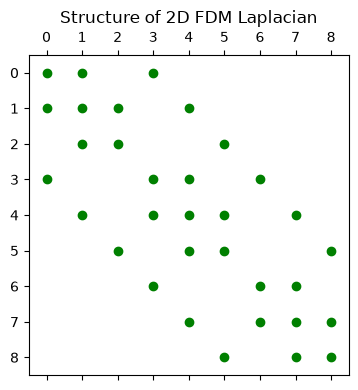

In [16]:
Nx, Ny = 4, 4 
dx, dy = Lx/Nx, Ly/Ny 
x, y = np.mgrid[dx:Lx-dx:(Nx-1)*1j, dy:Ly-dy:(Ny-1)*1j] 

A_fdm_small = FDLaplacian2D(Nx, Ny, dx, dy) 
print('Test FDM matrix A =\n', A_fdm_small.todense()) 
 
plt.figure(figsize=(5, 4)) 

plt.spy(A_fdm_small, marker='o', color='green', markersize=6)

plt.title('Structure of 2D FDM Laplacian') 
plt.tight_layout() 
plt.show()

### Question 4.2: Assemble, print, and test the symmetry of the FVM system matrix on a small grid (1 p)

In [19]:
Nx, Ny = 4, 4
dx, dy = Lx/Nx, Ly/Ny
x, y = np.mgrid[dx:Lx-dx:(Nx-1)*1j, dy:Ly-dy:(Ny-1)*1j]

A_fvm_small = create2DLFVM(Lx, Ly, Nx, Ny,  coeffK2 )

print('Test FVM matrix A =\n', A_fvm_small.todense())
print('Symmetry error =', np.linalg.norm((A_fvm_small - A_fvm_small.T).todense()))

Test FVM matrix A =
 [[ 2.7   -0.315  0.    -1.22   0.     0.     0.     0.     0.   ]
 [-0.315  3.6   -0.405  0.    -1.68   0.     0.     0.     0.   ]
 [ 0.    -0.405  4.5    0.     0.    -2.14   0.     0.     0.   ]
 [-1.22   0.     0.     3.4   -0.41   0.    -1.5    0.     0.   ]
 [ 0.    -1.68   0.    -0.41   4.8   -0.55   0.    -2.16   0.   ]
 [ 0.     0.    -2.14   0.    -0.55   6.2    0.     0.    -2.82 ]
 [ 0.     0.     0.    -1.5    0.     0.     4.1   -0.505  0.   ]
 [ 0.     0.     0.     0.    -2.16   0.    -0.505  6.    -0.695]
 [ 0.     0.     0.     0.     0.    -2.82   0.    -0.695  7.9  ]]
Symmetry error = 0.0


### Question 4.3 Assemble and compute FDM and FVM solutions on a finer grid (3 p)

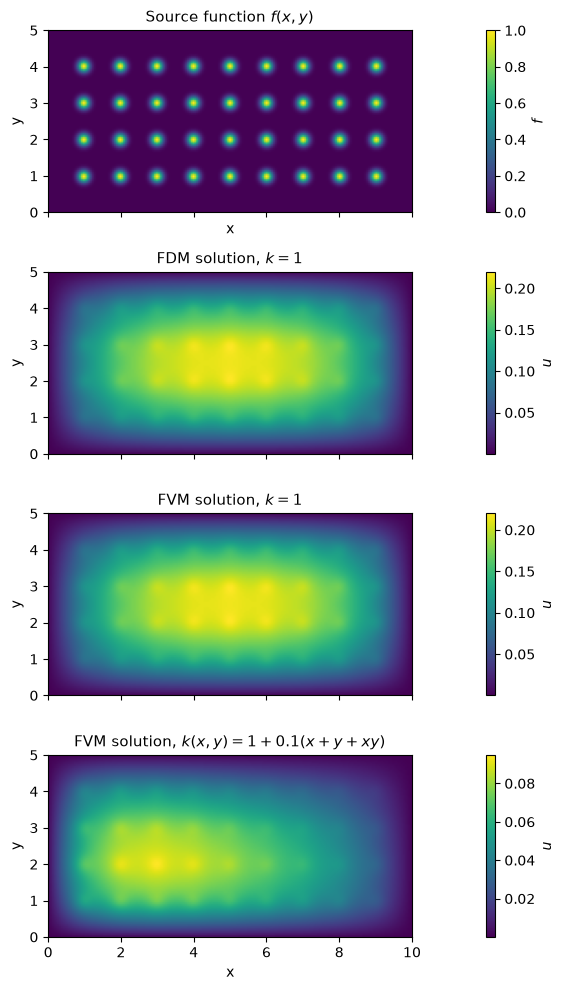

In [23]:
Nx, Ny = 200, 100
dx, dy = Lx/Nx, Ly/Ny
x, y = np.mgrid[dx:Lx-dx:(Nx-1)*1j, dy:Ly-dy:(Ny-1)*1j]
f = sourcefunc(x, y)


# ============================================================
# 1. Assemble and solve the three systems
# ============================================================

# The matrix assembly uses the ordering:
# [u_11, u_21, ..., u_(Nx-1,1), u_12, ...]
# so x varies fastest. Therefore use Fortran ordering.
f_vec = f.reshape(-1, order='F')

# ----- FDM, k = 1 -----
A_fdm = FDLaplacian2D(Nx, Ny, dx, dy)

u_fdm_vec = la.spsolve(A_fdm, f_vec)

u_fdm = u_fdm_vec.reshape((Nx-1, Ny-1), order='F')


# ----- FVM, k = 1 -----
A_fvm_k1 = create2DLFVM(Lx, Ly, Nx, Ny, coeffK1)

u_fvm_k1_vec = la.spsolve(A_fvm_k1, f_vec)

u_fvm_k1 = u_fvm_k1_vec.reshape((Nx-1, Ny-1), order='F')


# ----- FVM, variable k(x,y) -----
A_fvm_k2 = create2DLFVM(Lx, Ly, Nx, Ny, coeffK2)

u_fvm_k2_vec = la.spsolve(A_fvm_k2, f_vec)

u_fvm_k2 = u_fvm_k2_vec.reshape((Nx-1, Ny-1), order='F')


# 3. Visualizations as 2D images
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

im0 = axes[0].imshow(f.transpose(), extent=[0, Lx, 0, Ly], origin='lower', cmap='viridis')
axes[0].set_title('Source function $f(x,y)$', fontsize=11)
fig.colorbar(im0, ax=axes[0], label='$f$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# FDM solution, k = 1
im1 = axes[1].imshow(
    u_fdm.transpose(),
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='viridis'
)

axes[1].set_title('FDM solution, $k=1$', fontsize=11)
fig.colorbar(im1, ax=axes[1], label='$u$')
axes[1].set_ylabel('y')


# FVM solution, k = 1
im2 = axes[2].imshow(
    u_fvm_k1.transpose(),
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='viridis'
)

axes[2].set_title('FVM solution, $k=1$', fontsize=11)
fig.colorbar(im2, ax=axes[2], label='$u$')
axes[2].set_ylabel('y')


# FVM solution, variable k(x,y)
im3 = axes[3].imshow(
    u_fvm_k2.transpose(),
    extent=[0, Lx, 0, Ly],
    origin='lower',
    cmap='viridis'
)

axes[3].set_title(
    'FVM solution, $k(x,y)=1+0.1(x+y+xy)$',
    fontsize=11
)
fig.colorbar(im3, ax=axes[3], label='$u$')
axes[3].set_xlabel('x')
axes[3].set_ylabel('y')

plt.tight_layout()
plt.show()

### Question 4.4: Check RMSE between FDM and FVM solutions (1 p)

In [13]:
print('RMSE between FDM and FVM solutions =',
      np.sqrt(np.mean((u_fdm - u_fvm_k1)**2)))

RMSE between FDM and FVM solutions = 1.2033864339463539e-15


### Question 4.5: Horizontal cross-section profiling plot of FVM slutions (1 p)

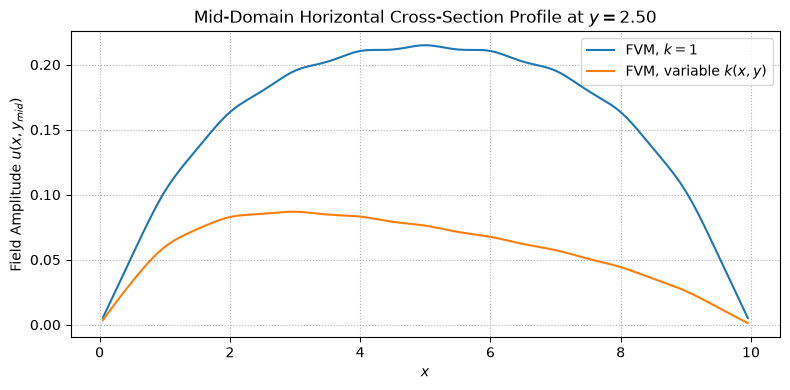

In [14]:
plt.figure(figsize=(8, 4))

mid_y = (Ny - 1) // 2
plt.plot(x[:, mid_y], u_fvm_k1[:, mid_y], label='FVM, $k=1$')
plt.plot(x[:, mid_y], u_fvm_k2[:, mid_y], label='FVM, variable $k(x,y)$')

plt.title(f'Mid-Domain Horizontal Cross-Section Profile at $y = {Ly/2:.2f}$', fontsize=12)
plt.xlabel('$x$')
plt.ylabel('Field Amplitude $u(x, y_{mid})$')
plt.grid(True, linestyle=':')
plt.legend() 
plt.tight_layout()
plt.show()

### 📝 Section 5: Analysis & Discussion (4 p)

5.1 According to the Maximum Principle, the solution for $k(x,y)=1$ is expected to.

5.2 Solutions obtained with the FD and FV Methods for $k(x,y)=1$ are expected to...

5.3 At the boundary, the solutions are expected to...

5.4 With the inhomogeneous $k(x,y)$, the solution is expected to...


QUESTION 5.1

For the constant coefficient case, the governing equation is $ -\Delta u = f, $ with $ f(x,y) \geq 0 $ and homogeneous Dirichlet boundary conditions $ u = 0$ on $ \partial\Omega. $

Since $ -\Delta u = f \geq 0, $ we have $ \Delta u \leq 0, $ so the solution is superharmonic. According to the minimum principle, the minimum value of a non-constant superharmonic function is attained on the boundary. Because the prescribed boundary value is zero,

$$
\min_{\overline{\Omega}} u
=
\min_{\partial\Omega} u
=
0
$$

Therefore, $ u(x,y) \geq 0$ in $\Omega. $ Hence the numerical solution is expected to remain non-negative throughout
the domain, rising above zero in the interior in response to the positive
source terms and returning to zero at the boundary.


QUESTION 5.2

For $ k(x,y)=1, $ the finite-volume discretization reduces to the same five-point stencil as the finite-difference discretization. Both methods therefore approximate $ -\Delta u = f $ using the discrete relation

$$
\left(
\frac{2}{h_x^2}
+
\frac{2}{h_y^2}
\right)u_{i,j}
-
\frac{u_{i-1,j}+u_{i+1,j}}{h_x^2}
-
\frac{u_{i,j-1}+u_{i,j+1}}{h_y^2}
=
f_{i,j}.
$$

Consequently, on the same uniform grid the FD and FV methods are expected
to produce essentially identical solutions, $ u_{\mathrm{FD}} \approx u_{\mathrm{FV}}. $

The RMSE between both solutions should therefore be close to machine/floating-point precision,

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
u_{\mathrm{FD},i}
-
u_{\mathrm{FV},i}
\right)^2
}
\approx 0.
$$

Any remaining difference is expected to result only from floating-point
round-off error.

Regarding the behaviour of the numerical solutions, the lecture shows that the matrices arising from both the FDM and FVM discretizations are monotone. Hence,

$$ A\mathbf{u}\geq 0 \Longrightarrow \mathbf{u}\geq 0. $$

Since the discrete system satisfies $ A\mathbf{u}=\mathbf{f}, $ and the source is non-negative, $ \mathbf{f}\geq 0, $ it follows that $ \mathbf{u}\geq 0. $

This is the discrete analogy of the minimum principle discussed in Question 5.1: neither the FDM nor the FVM solution should develop negative values when the source is non-negative and homogeneous Dirichlet boundary conditions are imposed.


QUESTION 5.3

The problem is subject to homogeneous Dirichlet boundary conditions, $u(x,y)=0, (x,y)\in\partial\Omega. $ Hence, after the prescribed boundary values are included, both the finite-difference and finite-volume approximations satisfy $ u_h(0,y)=u_h(L_x,y)=0, u_h(x,0)=u_h(x,L_y)=0 $ exactly at all boundary nodes. Since the source term is non-negative, the minimum principle implies that the solution cannot attain a value below its boundary minimum. Therefore, $ u_h(x,y)\geq 0 $ throughout the computational domain.

Consequently, the numerical solution rises from the imposed zero values at the boundary to positive values in the interior and decreases again toward zero when another boundary is approached. This behaviour is consistent with both the imposed homogeneous Dirichlet boundary conditions and the continuous and discrete minimum principles. The plotted numerical fields contain only the interior unknowns; the zero boundary values are prescribed separately and are therefore not included in the solved interior solution vector.


QUESTION 5.4

For the inhomogeneous case, the diffusion coefficient is $ k(x,y) = 1+0.1(x+y+xy). $ The governing equation is now

$$ -\nabla\cdot
\left(
k(x,y)\nabla u
\right)
=
f.
$$

The diffusive flux is given by $ \mathbf{q} = -k(x,y)\nabla u. $ Thus, a larger value of $k$ produces a larger diffusive flux for a given
gradient. Since $ k(x,y) $ increases as $x$ and $y$ increase, diffusion becomes progressively stronger toward the upper-right part of the domain. The solution is therefore no longer expected to have the same spatial symmetry as the constant-coefficient solution.

In regions where $k$ is larger, the same source can be transported with a smaller gradient. Consequently, the solution is expected to become flatter and generally have smaller amplitudes in the high-$k$ region than in the corresponding constant-$k$ solution. For example, along the horizontal cross-section $ y=\frac{L_y}{2}=2.5, $ the coefficient becomes

$$
k(x,2.5)
=
1+0.1(x+2.5+2.5x)
=
1.25+0.35x.
$$

Hence the diffusion coefficient increases continuously from left to right along this profile. The variable-$k$ FVM solution is therefore expected to become asymmetric relative to the $k=1$ profile, with stronger diffusion and reduced gradients toward increasing $x$.